In [163]:
from bauer.utils.data import load_garcia2022
from bauer.models import RiskModel, RiskLapseModel
import numpy as np
import pandas as pd
import seaborn as sns
from bauer.utils.plotting import plot_ppc

In [166]:
df = load_garcia2022(task='risk')

In [167]:
df = df.xs('non-symbolic', 0, 'format')

In [122]:
model = RiskLapseModel(data=df, prior_estimate='klw', fit_seperate_evidence_sd=False)

In [123]:
model.build_estimation_model()

In [124]:
idata = model.sample(1000, 1000)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [evidence_sd_mu_untransformed, evidence_sd_sd, evidence_sd_offset, prior_std_mu_untransformed, prior_std_sd, prior_std_offset, p_lapse_mu_untransformed, p_lapse_sd, p_lapse_offset]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 391 seconds.
There were 1 divergences after tuning. Increase `target_accept` or reparameterize.


        evidence_sd          
            hdi_low  hdi_high
subject                      
1          0.096019  0.201830
2          0.096332  0.193179
3          0.212308  0.413169
4          0.154254  0.247327
5          0.171357  0.383304
...             ...       ...
60         0.127550  0.195921
61         0.181170  0.297829
62         0.080059  0.174269
63         0.120495  0.220712
64         0.111684  0.237613

[64 rows x 2 columns]


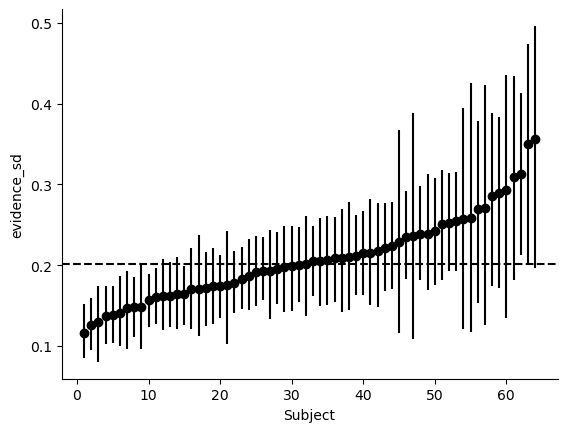

In [128]:
from bauer.utils.plotting import plot_subjectwise_parameters
plot_subjectwise_parameters(idata, parameter='evidence_sd')

          p_lapse          
          hdi_low  hdi_high
subject                    
1        0.000002  0.102666
2        0.000018  0.069063
3        0.000004  0.085074
4        0.000007  0.069959
5        0.000015  0.280668
...           ...       ...
60       0.000014  0.037388
61       0.000003  0.048286
62       0.000001  0.030730
63       0.000011  0.084042
64       0.000008  0.022260

[64 rows x 2 columns]


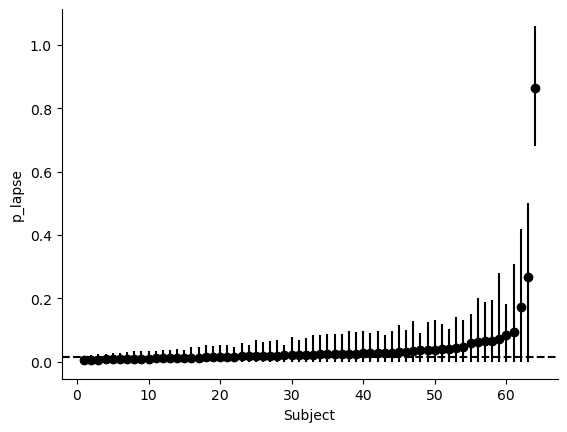

In [129]:
plot_subjectwise_parameters(idata, parameter='p_lapse')

              rnp          
          hdi_low  hdi_high
subject                    
1        0.442396  0.510226
2        0.532767  0.549477
3        0.114421  0.238743
4        0.441312  0.510992
5        0.511231  0.547150
...           ...       ...
60       0.346904  0.398192
61       0.257927  0.327464
62       0.533359  0.549510
63       0.354039  0.410384
64       0.163096  0.252894

[64 rows x 2 columns]


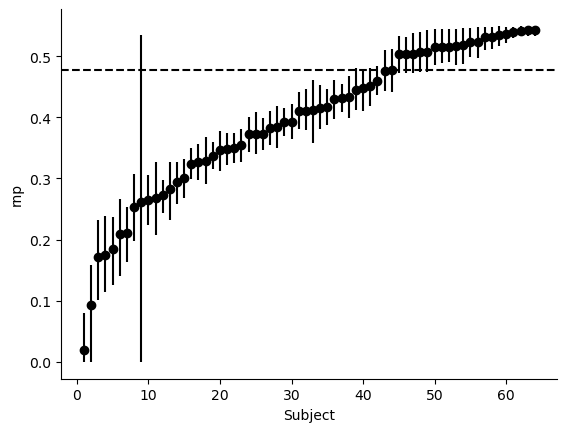

In [218]:
def get_rnp(evidence_sd, prior_std, p=.55):
    beta = prior_std**2 / (evidence_sd**2 + prior_std**2)
    return np.clip(np.exp(-(1./beta) * np.log(1./p)), 0, 1)

idata.posterior['rnp'] = get_rnp(idata.posterior['evidence_sd'], idata.posterior['prior_std'])
idata.posterior['rnp_mu'] = get_rnp(idata.posterior['evidence_sd_mu'], idata.posterior['prior_std_mu'])

plot_subjectwise_parameters(idata, parameter='rnp')

In [219]:
ppc = model.ppc(df, idata)

Sampling: [ll_bernoulli]


In [227]:
from bauer.utils.plotting import plot_ppc, summarize_ppc, plot_prediction, cluster_offers
import matplotlib.pyplot as plt

In [228]:
df['log(n2/n1)'] = np.log(df['n2'] / df['n1'])

In [231]:

def plot_ppc(df, ppc, exp_type='magnitude', plot_type=1, var_name='p', level='subject', col_wrap=5, n_clusters=13):

    if exp_type  == 'magnitude':
        x = 'log(n2/n1)'

        if 'log(n2/n1)' not in ppc.index.names:
            if 'frac'  in ppc.index.names:
                ppc['log(n2/n1)'] = np.log(ppc.index.get_level_values('frac'))
            else:
                ppc['log(n2/n1)'] = np.log(ppc.index.get_level_values('n2')) - np.log(ppc.index.get_level_values('n1'))

            ppc.set_index('log(n2/n1)', append=True)

    assert (var_name in ['p', 'll_bernoulli'])

    ppc = ppc.xs(var_name, 0, 'variable').copy()


    df = df.copy()

    # Make sure that we group data from (Roughly) same fractions
    if not (df.groupby(['subject', x]).size().groupby('subject').size() < (n_clusters+1)).all():
        if level == 'subject':
            df[x] = df.groupby(['subject'],
                                            group_keys=False).apply(lambda d: cluster_offers(d, n_clusters, x))
        else:
            df[x] = cluster_offers(df, n_clusters, x)

    if plot_type == 0:
        groupby = [x]
    elif plot_type == 1:
        groupby = [x, 'n1']
    elif plot_type == 2:
        groupby = ['n1']
    else:
        raise NotImplementedError

    if level == 'group':
        ppc = ppc.groupby(['subject']+groupby).mean()

    if level == 'subject':
        groupby = ['subject'] + groupby

    ppc_summary = summarize_ppc(ppc, groupby=groupby)
    p = df.groupby(groupby).mean()[['choice']]
    ppc_summary = ppc_summary.join(p, how='outer').reset_index()

    if plot_type in [0]:
        fac = sns.FacetGrid(ppc_summary,
                            col='subject' if level == 'subject' else None,
                            col_wrap=col_wrap if level == 'subject' else None)
        fac.map_dataframe(plot_prediction, x=x)
        fac.map(plt.scatter, x, 'choice')

    elif plot_type in [1]:
        fac = sns.FacetGrid(ppc_summary,
                            hue='n1',
                            col='subject' if level == 'subject' else None,
                            col_wrap=col_wrap if level == 'subject' else None)
        fac.map_dataframe(plot_prediction, x=x)
        fac.map(plt.scatter, x, 'choice')

    if plot_type in [2]:
        fac = sns.FacetGrid(ppc_summary,
                            col='subject' if level == 'subject' else None,
                            col_wrap=col_wrap if level == 'subject' else None)
        fac.map_dataframe(plot_prediction, x='n1')
        fac.map(plt.scatter, 'n1', 'choice')
    
    fac.add_legend()

    return fac

/Users/gdehol/git/bauer/bauer/utils/bayes.py:38: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = pd.DataFrame(az.hdi(ppc.T.values), index=ppc.index,


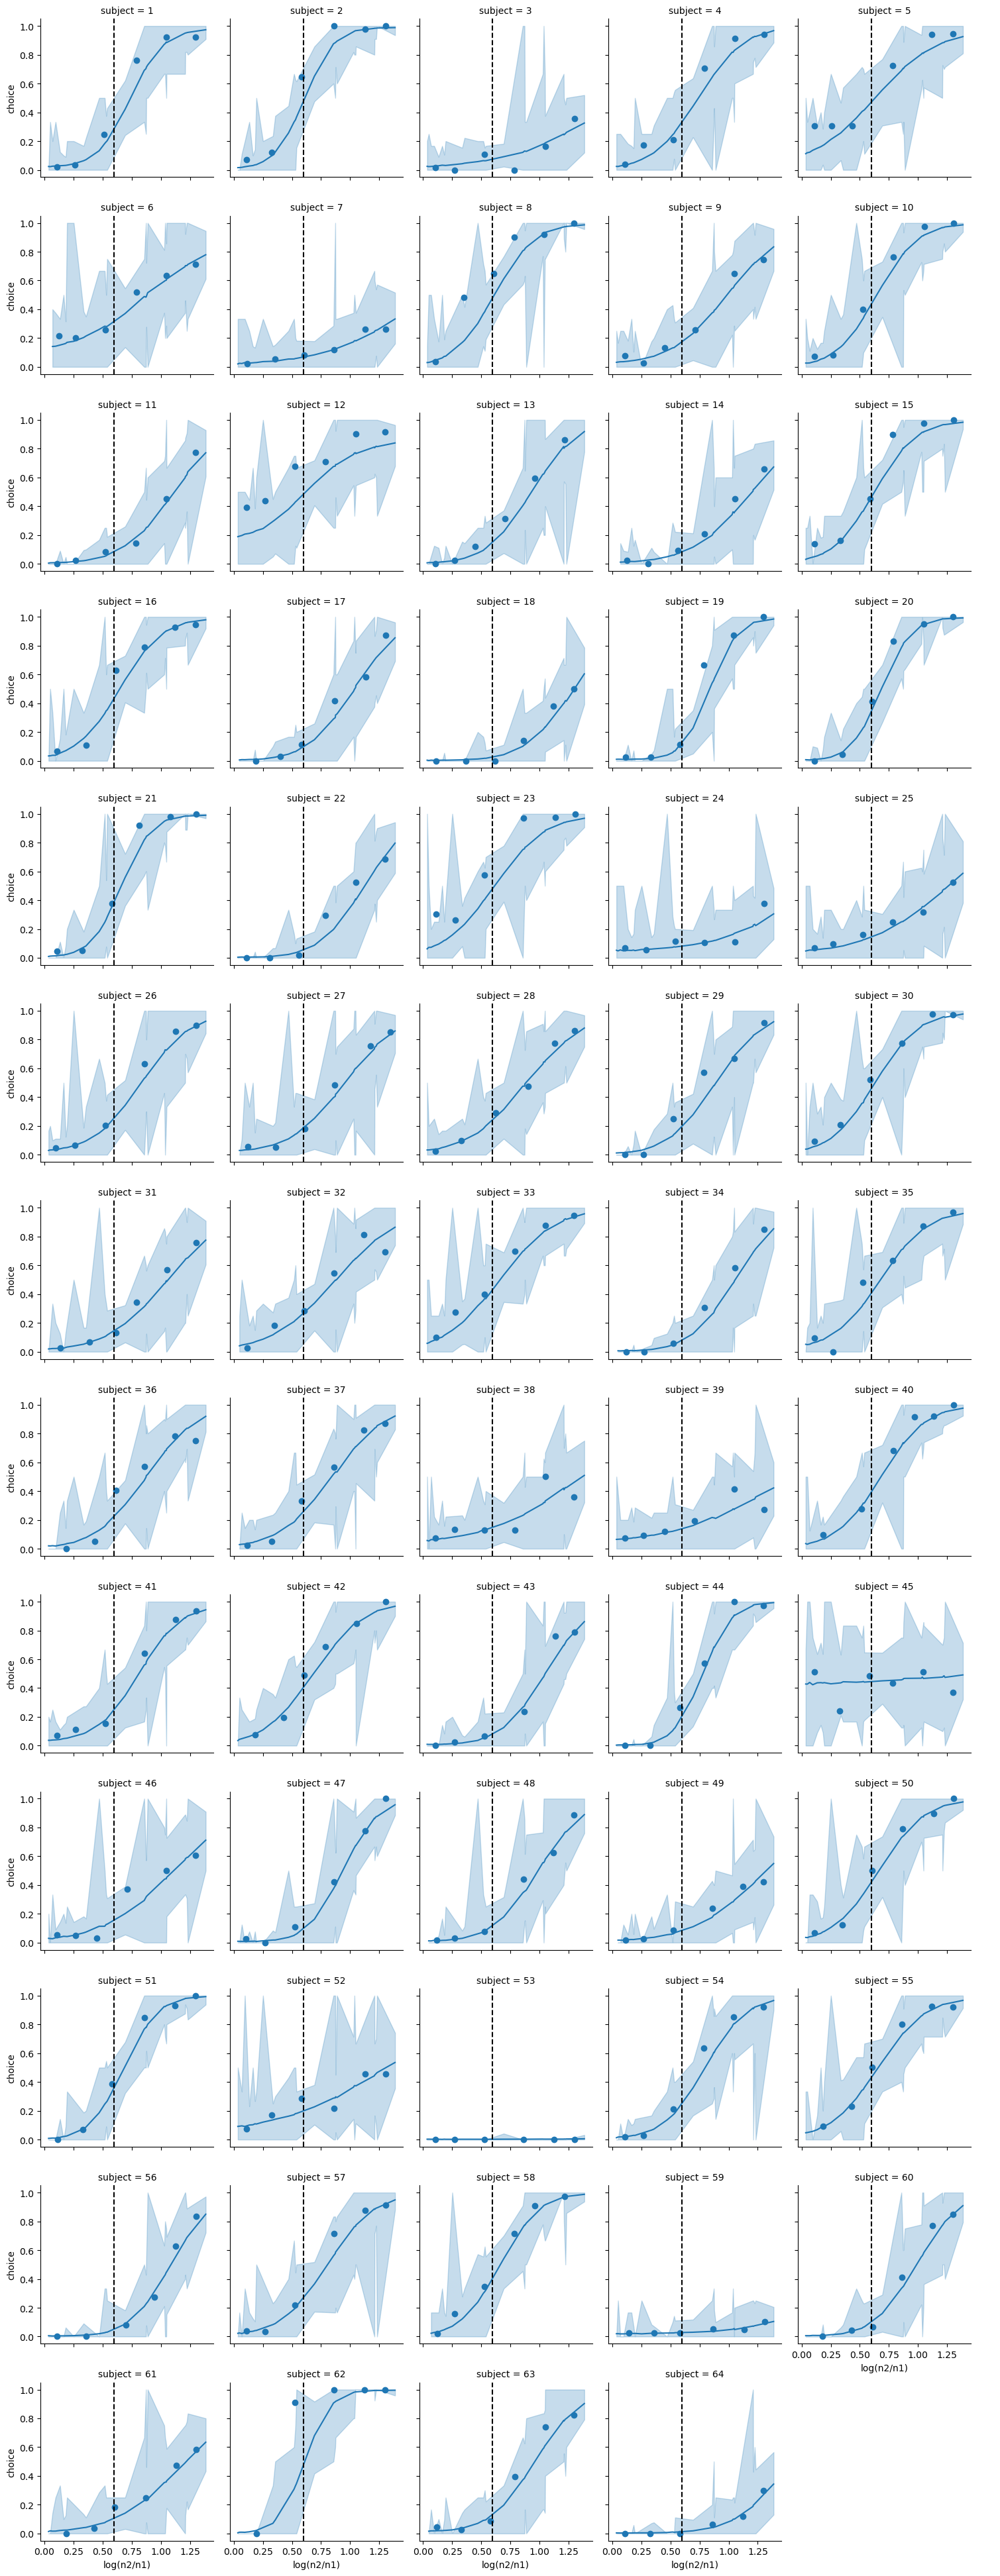

In [232]:
g = plot_ppc(df, ppc, var_name='ll_bernoulli', plot_type=0, level='subject', n_clusters=6)

g.map(plt.axvline, x=np.log(1./0.55), c='k', ls='--')